c:\Users\RAJ\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


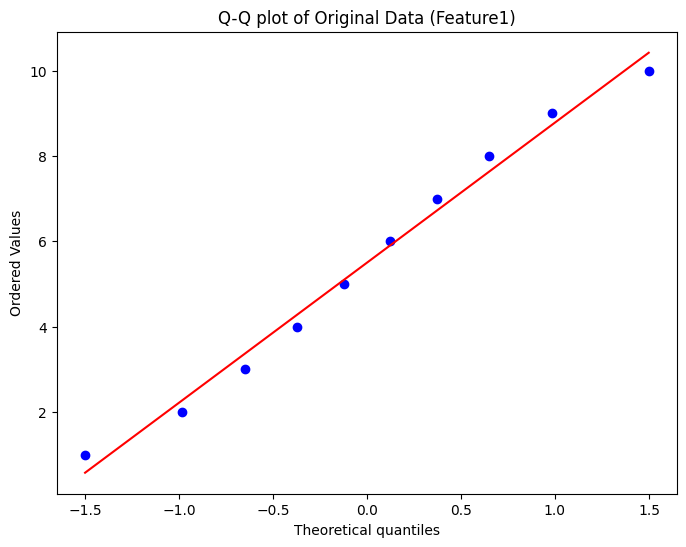

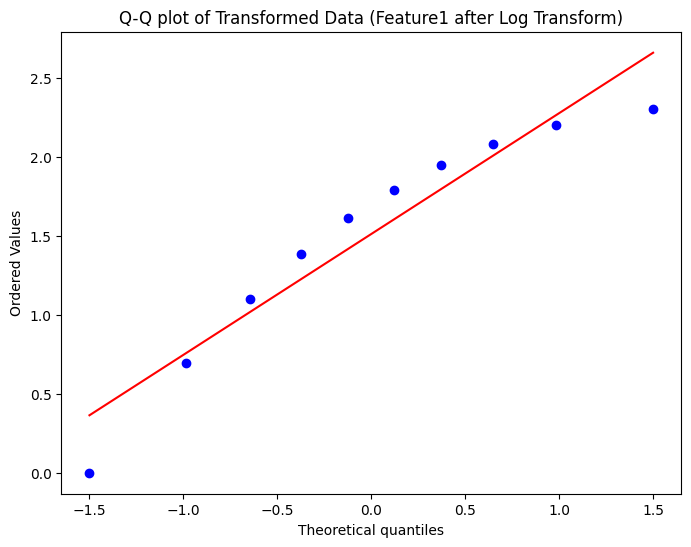

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import FunctionTransformer

# Example dataset
data = {'Feature1': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Feature2': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]}

# Convert to DataFrame
df = pd.DataFrame(data)

# Define a custom function (log transform for better visualization)
def log_transform(x):
    return np.log(x)

# Create a FunctionTransformer with the custom log function
transformer = FunctionTransformer(log_transform, validate=True)

# Apply the transformer to the data
transformed_data = transformer.transform(df)

# Convert back to DataFrame for better readability
transformed_df = pd.DataFrame(transformed_data, columns=df.columns)

# Function to plot Q-Q plot
def plot_qq(data, title="Q-Q plot"):
    plt.figure(figsize=(8, 6))
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(title)
    plt.show()

# Plot the Q-Q plot for the original data (Feature1)
plot_qq(df['Feature1'], title="Q-Q plot of Original Data (Feature1)")

# Plot the Q-Q plot for the transformed data (Feature1 after log transform)
plot_qq(transformed_df['Feature1'], title="Q-Q plot of Transformed Data (Feature1 after Log Transform)")


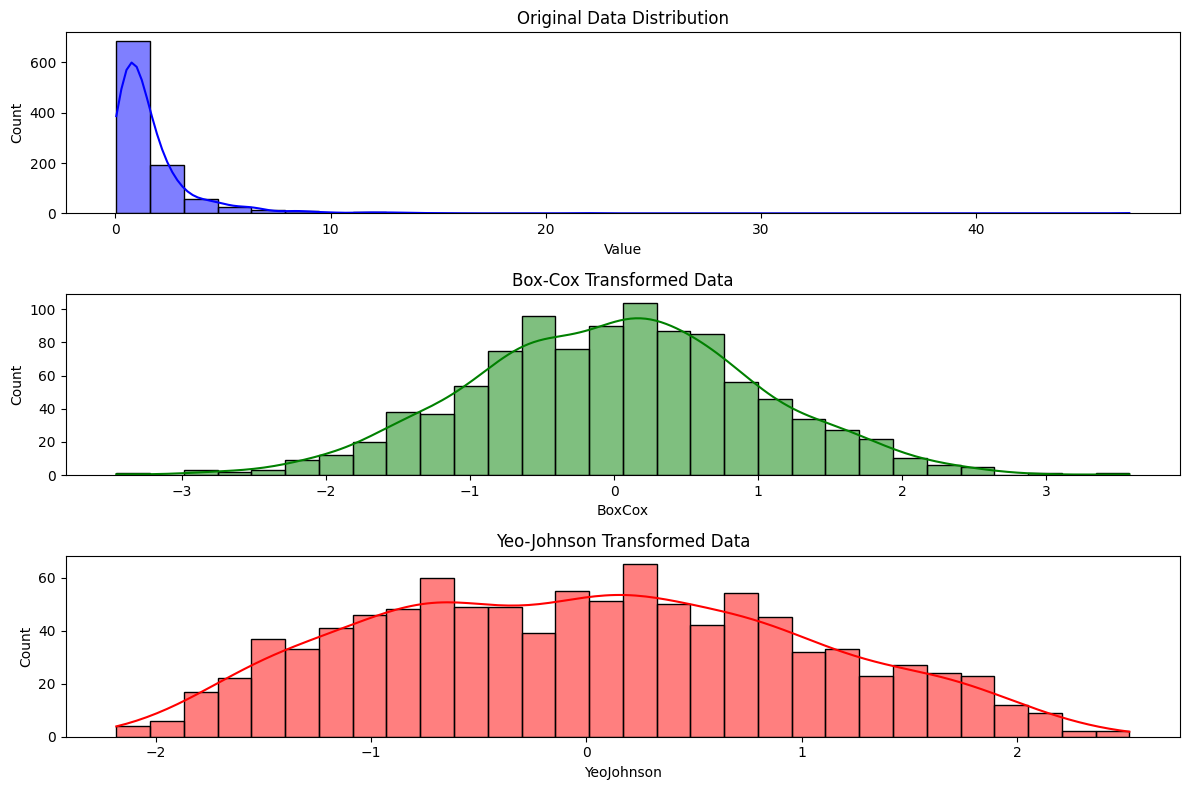

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from sklearn.preprocessing import PowerTransformer

np.random.seed(42)
data = np.random.lognormal(mean=0, sigma=1, size=1000)

# Create a DataFrame for easy handling
df = pd.DataFrame(data, columns=["Value"])

# Apply Box-Cox Transformation (Box-Cox requires strictly positive data)
# Since Box-Cox works only with positive data, we need to make sure all values are positive
# If the data has zero or negative values, we would need to shift the data.
df_boxcox = df.copy()
df_boxcox["BoxCox"], _ = boxcox(df_boxcox["Value"])

# Apply Yeo-Johnson Transformation (Yeo-Johnson works with both positive and negative values)
scaler = PowerTransformer(method='yeo-johnson')
df_yeojohnson = df.copy()
df_yeojohnson["YeoJohnson"] = scaler.fit_transform(df_yeojohnson[["Value"]])

# Plotting the original data, Box-Cox transformed, and Yeo-Johnson transformed
plt.figure(figsize=(12, 8))

# Original data
plt.subplot(3, 1, 1)
sns.histplot(df["Value"], kde=True, color='blue', bins=30)
plt.title('Original Data Distribution')

# Box-Cox transformed data
plt.subplot(3, 1, 2)
sns.histplot(df_boxcox["BoxCox"], kde=True, color='green', bins=30)
plt.title('Box-Cox Transformed Data')

# Yeo-Johnson transformed data
plt.subplot(3, 1, 3)
sns.histplot(df_yeojohnson["YeoJohnson"], kde=True, color='red', bins=30)
plt.title('Yeo-Johnson Transformed Data')

plt.tight_layout()
plt.show()